# 05 — General Plate-Solving Checkpoint

**Purpose:** Run the preliminary astrometry.net plate solve and establish \
`working/general_platesolve/` as the checkpoint directory for Phase 1 outputs.

This is **Phase 1** of the pipeline — source extraction and broad field identification:

| Step | Module | Output |
|------|--------|--------|
| 1 | `extractor.stars.extract_stars()` | Detected source pixel positions |
| 2 | `extractor.platesolve.platesolve()` | Initial WCS, reference-star list, product bundle |

The astrometry.net result is useful for:
- Approximate field center / pointing.
- Submitted source pixel locations.
- Astrometry.net reference-star list (`rdls.fits`).
- An initial WCS for field orientation.

**This initial WCS is not the final precision distortion model.** WCS residuals \
of 1–3 px (≈80–250 arcsec at this plate scale) are expected and documented in \
the `wcs_` diagnostic notebooks. Later stages will build a custom distortion \
model using these Phase 1 products as inputs.

In [1]:
import sys
import pickle
import shutil
import warnings
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits as afits
from astropy.wcs import WCS
from astropy.table import Table
from scipy.ndimage import gaussian_filter

ROOT        = Path('..').resolve()
FITS_PATH   = sorted((ROOT / 'data').glob('*.fit'))[0]
WORKING_DIR = ROOT / 'working' / 'general_platesolve'
WORKING_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(ROOT))
from extractor.platesolve import platesolve, wcs_summary, has_sip

plt.rcParams.update({
    'figure.facecolor': '#111', 'axes.facecolor': '#111',
    'axes.edgecolor': '#888',   'text.color': 'white',
    'xtick.color': '#aaa',      'ytick.color': '#aaa',
    'axes.labelcolor': 'white', 'grid.color': '#333',
    'axes.titlecolor': 'white', 'legend.facecolor': '#222',
    'legend.edgecolor': '#555',
})

with afits.open(FITS_PATH) as hdul:
    image = hdul[0].data.astype(float)
h, w = image.shape
print(f'Image  : {FITS_PATH.name}  ({w} x {h} px)')
print(f'Output : {WORKING_DIR}')


Image  : fuji6_asi178_100_15s.fit  (3096 x 2080 px)
Output : C:\Users\bassd\Research\Spectra Angle\spectrangle\working\general_platesolve


## Phase 1 — Run or Load the Baseline Solve

The cell below seeds `working/general_platesolve/result.pkl` from the existing \
`out/wcs_diagnostics/` cache if it exists, avoiding unnecessary re-submission \
to astrometry.net.  If no prior result is available the notebook will submit \
live (requires API key in `astrometry_api.txt`).

In [2]:
_cache_path = WORKING_DIR / 'result.pkl'
_old_caches = [
    ROOT / 'out' / 'wcs_diagnostics' / 'platesolve_result.pkl',
    ROOT / 'out' / 'wcs_diagnostics' / 'solve_default.pkl',
]

if not _cache_path.exists():
    for _src in _old_caches:
        if _src.exists():
            shutil.copy2(_src, _cache_path)
            print(f'Seeded working cache from {_src.relative_to(ROOT)}')
            break
    else:
        print('No existing cache found — will submit to astrometry.net.')
else:
    print(f'Working cache already present: {_cache_path.name}')


Seeded working cache from out\wcs_diagnostics\platesolve_result.pkl


In [3]:
result = platesolve(
    FITS_PATH,
    use_source_list=True,
    max_sources=300,
    mask_spectra=True,
    write=False,
    fetch_products=True,
    save_products_dir=WORKING_DIR,
    cache=WORKING_DIR / 'result.pkl',
    verbose=True,
)

if result is None:
    raise RuntimeError('Plate solve failed — check API key and astrometry.net status.')
print('Solve complete.')


Loading cached result from result.pkl
Solve complete.


In [4]:
with warnings.catch_warnings():
    warnings.simplefilter('ignore')
    wcs = WCS(result.header)

cx, cy = w / 2.0, h / 2.0
ra0, dec0 = wcs.all_pix2world([[cx, cy]], 0)[0]
ra1, dec1 = wcs.all_pix2world([[cx + 1, cy]], 0)[0]
cosd      = np.cos(np.radians(dec0))
scale_as  = np.hypot((ra1 - ra0) * cosd, dec1 - dec0) * 3600
fov_x_deg = scale_as * w / 3600
fov_y_deg = scale_as * h / 3600

print('=== General Plate-Solve Checkpoint ===')
print(f'  Image              : {FITS_PATH.name}  ({w} x {h} px)')
print(f'  Submitted sources  : {len(result.detected_x)}')
print(f'  Submission ID      : {result.submission_id}')
print(f'  Job ID             : {result.job_id}')
print(f'  Solve status       : {result.status}')
print(f'  WCS centre RA/Dec  : {ra0:.4f} deg / {dec0:.4f} deg')
print(f'  Plate scale        : {scale_as:.1f}" / px')
print(f'  FOV (approx)       : {fov_x_deg:.2f} deg x {fov_y_deg:.2f} deg')
print(f'  SIP distortion     : {has_sip(result.header)}')
print()
print('WCS keywords:')
print(wcs_summary(result.header))
print()
print('Fetch status:')
for k, v in result.fetch_status.items():
    tag = 'OK' if v == 'ok' else 'FAILED'
    print(f'  {k:12s}: {tag}')
print()
print('Files written to working dir:')
for p in sorted(WORKING_DIR.iterdir()):
    print(f'  {p.name:<35s}  {p.stat().st_size:>10,} bytes')


=== General Plate-Solve Checkpoint ===
  Image              : fuji6_asi178_100_15s.fit  (3096 x 2080 px)
  Submitted sources  : 255
  Submission ID      : 14945354
  Job ID             : 15781285
  Solve status       : success
  WCS centre RA/Dec  : 113.4038 deg / 30.3918 deg
  Plate scale        : 80.0" / px
  FOV (approx)       : 68.81 deg x 46.23 deg
  SIP distortion     : True

WCS keywords:
  CTYPE1  : RA---TAN-SIP
  CTYPE2  : DEC--TAN-SIP
  CRVAL1  : 120.61262
  CRVAL2  : 29.788056
  CRPIX1  : 1286.8585
  CRPIX2  : 1140.5638
  CD1_1   : -0.0218561
  CD1_2   : 0.00514579
  CD2_1   : -0.00525836
  CD2_2   : -0.0219369
  SIP     : yes (order 2)

Fetch status:
  corr        : OK
  axy         : OK
  rdls        : OK
  image_rd    : OK

Files written to working dir:
  result.pkl                              162,970 bytes


## Saved Product Tables

Load each astrometry.net product from `working/general_platesolve/`.  \
`rdls.fits` (the reference-catalog star list) is the most important output \
for later pipeline stages.

In [5]:
def _load_fits_table(path):
    """Load the first BinTableHDU from a FITS file."""
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        with afits.open(path) as hdul:
            tbl_hdu = next(
                (h for h in hdul if isinstance(h, (afits.BinTableHDU, afits.TableHDU))),
                None)
            return Table(tbl_hdu.data) if tbl_hdu is not None else None

def _get_table(attr, filename):
    tbl = getattr(result, attr, None)
    if tbl is None:
        p = WORKING_DIR / filename
        if p.exists():
            tbl = _load_fits_table(p)
    return tbl

axy_tbl  = _get_table('axy_table',         'axy.fits')
rdls_tbl = _get_table('rdls_table',         'rdls.fits')
imrd_tbl = _get_table('image_radec_table',  'image-radec.fits')
corr_tbl = _get_table('corr_table',         'corr.fits')

print('Product tables:')
for name, tbl in [('axy', axy_tbl), ('rdls', rdls_tbl),
                  ('image_rd', imrd_tbl), ('corr', corr_tbl)]:
    if tbl is not None:
        print(f'  {name:12s}: {len(tbl):4d} rows   cols={tbl.colnames}')
    else:
        print(f'  {name:12s}: not available')

if rdls_tbl is not None:
    print()
    print('rdls reference catalog — first 5 rows:')
    print(rdls_tbl[:5])


Product tables:
  axy         :  255 rows   cols=['X', 'Y']
  rdls        :  179 rows   cols=['MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG', 'RA', 'DEC']
  image_rd    :  255 rows   cols=['ra', 'dec', 'x', 'y']
  corr        :   48 rows   cols=['field_x', 'field_y', 'field_ra', 'field_dec', 'index_x', 'index_y', 'index_ra', 'index_dec', 'index_id', 'field_id', 'match_weight', 'MAG_BT', 'MAG_VT', 'MAG_HP', 'MAG']

rdls reference catalog — first 5 rows:
MAG_BT MAG_VT ...         RA                DEC        
------ ------ ... ------------------ ------------------
 1.605   1.67 ...  81.57290803910979  28.60787346410264
   0.0  2.024 ...  99.42792639881719 16.399414806626393
 2.552  2.602 ...  89.93016692882802 37.212747210424666
 4.666   2.83 ...  74.24839888276797 33.166132506305985
 3.358  3.128 ... 134.80338943598048  48.04231360995288


## Checkpoint Figure — Source / Reference Overlay

One figure: submitted sources (white dots) and astrometry.net reference stars \
from `rdls.fits` projected through the initial WCS (cyan crosses). \
This is the visual checkpoint for Phase 1.

C:\Users\bassd\AppData\Local\Temp\ipykernel_9464\816268218.py:34: UserWarning: You passed a edgecolor/edgecolors ('cyan') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(rdls_px[in_frame, 0], rdls_px[in_frame, 1],


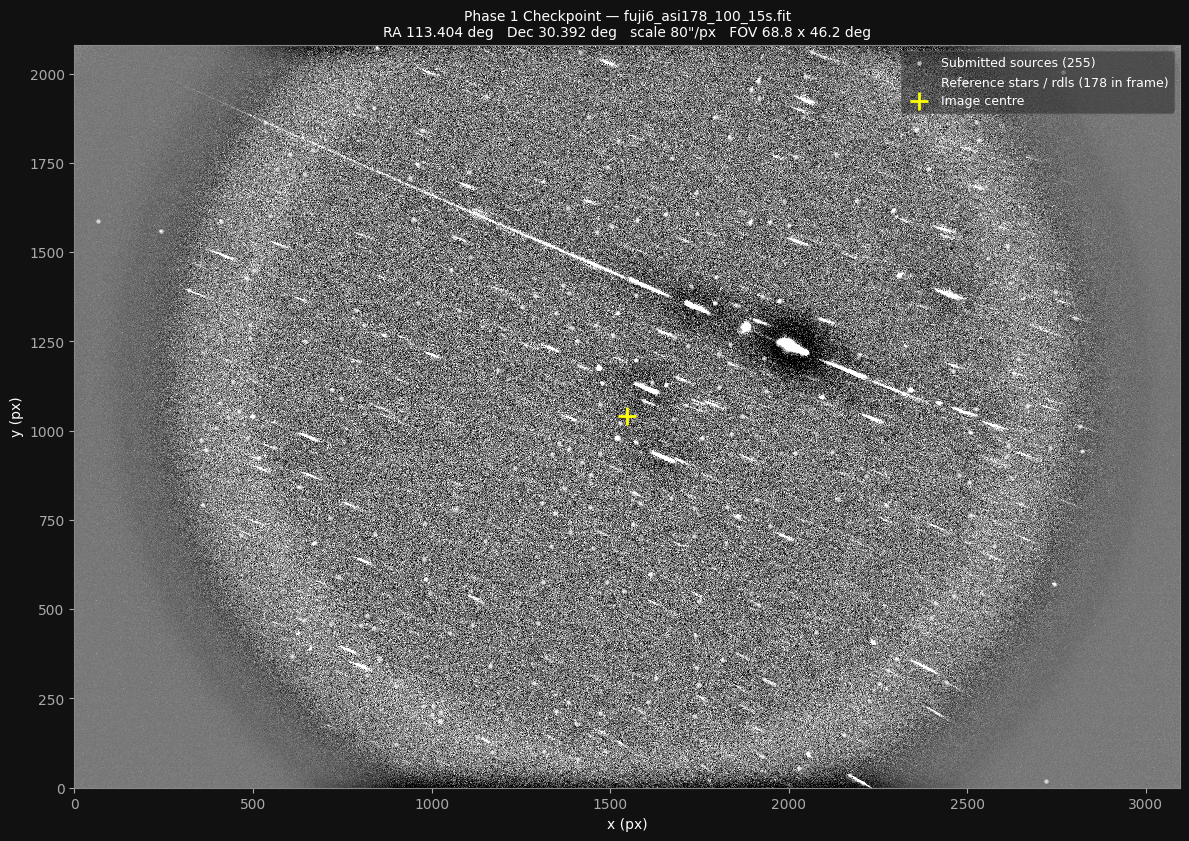

Saved general_platesolve_overlay.png and general_platesolve_overlay.pdf


In [6]:
def _gcol(tbl, *names):
    lm = {c.strip().lower(): c for c in tbl.colnames}
    for n in names:
        k = lm.get(n.strip().lower())
        if k is not None:
            return np.asarray(tbl[k], dtype=float)
    return None

fig, ax = plt.subplots(figsize=(12, 9))

# Arcsinh-stretched background-subtracted display
bg   = gaussian_filter(image, sigma=50)
disp = np.arcsinh((image - bg) / max(np.std(image - bg), 1.0))
vmin, vmax = np.percentile(disp, [1, 99])
ax.imshow(disp, origin='lower', cmap='gray', vmin=vmin, vmax=vmax,
          interpolation='nearest')

# Submitted sources
ax.scatter(result.detected_x, result.detected_y,
           s=10, c='white', alpha=0.65, linewidths=0,
           label=f'Submitted sources ({len(result.detected_x)})')

# Reference stars projected via initial WCS
if rdls_tbl is not None:
    rdls_ra  = _gcol(rdls_tbl, 'ra')
    rdls_dec = _gcol(rdls_tbl, 'dec')
    if rdls_ra is not None:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            rdls_px = wcs.all_world2pix(
                np.column_stack([rdls_ra, rdls_dec]), 0)
        in_frame = ((rdls_px[:, 0] >= 0) & (rdls_px[:, 0] < w) &
                    (rdls_px[:, 1] >= 0) & (rdls_px[:, 1] < h))
        ax.scatter(rdls_px[in_frame, 0], rdls_px[in_frame, 1],
                   s=100, c='none', edgecolors='cyan', linewidths=1.2,
                   marker='+',
                   label=f'Reference stars / rdls ({in_frame.sum()} in frame)')

# Image centre marker
ax.scatter([cx], [cy], s=150, marker='+', c='yellow',
           linewidths=2, label='Image centre', zorder=10)

ax.set_xlim(0, w); ax.set_ylim(0, h)
ax.set_xlabel('x (px)'); ax.set_ylabel('y (px)')
ax.set_title(
    f'Phase 1 Checkpoint — {FITS_PATH.name}\n'
    f'RA {ra0:.3f} deg   Dec {dec0:.3f} deg   '
    f'scale {scale_as:.0f}"/px   FOV {fov_x_deg:.1f} x {fov_y_deg:.1f} deg',
    fontsize=10)
ax.legend(loc='upper right', fontsize=9, framealpha=0.5)

fig.tight_layout()
out_png = WORKING_DIR / 'general_platesolve_overlay.png'
out_pdf = WORKING_DIR / 'general_platesolve_overlay.pdf'
fig.savefig(out_png, dpi=150, bbox_inches='tight')
fig.savefig(out_pdf, bbox_inches='tight')
plt.show()
print(f'Saved {out_png.name} and {out_pdf.name}')


## Checkpoint Summary

The preliminary astrometry.net solve has completed. All Phase 1 outputs are \
now in `working/general_platesolve/`.

| File | Contents |
|------|----------|
| `result.pkl` | Cached `PlatesolveResult` (header + source arrays + tables) |
| `axy.fits` | Astrometry.net internal source detection list |
| `rdls.fits` | **Reference-catalog stars used in solve** |
| `image-radec.fits` | Submitted sources projected to sky coordinates |
| `corr.fits` | Astrometry.net correspondence pairs (informational) |
| `solve_metadata.json` | Job IDs, source counts, fetch outcomes |
| `general_platesolve_overlay.png/.pdf` | This checkpoint figure |

### Important caveats

- The field centre and plate scale from astrometry.net are **approximate**.
- WCS residuals of 1–3 px are known and expected at this wide-field plate scale.
- `corr.fits` has limited spatial coverage (mostly near the field centre) and \
  is not representative of edge-of-field performance.

### Next steps

Later pipeline stages will consume these Phase 1 products to build a \
**custom distortion model**:
1. Match `result.detected_x/y` to `rdls.fits` reference stars using a \
   flexible polynomial or SIP-like distortion model.
2. Fit per-star residuals to produce a precision pixel→sky mapping.
3. Apply the refined mapping to convert spectral trace directions to precise \
   sky-frame grating angles.